# Architecture Detection Pipeline
notebook from
**From pixels to beasts — Dr. Marion Charpier, DEVILL**

Pipeline: GroundingDINO → SAM → ROI → CLIP

Prompt hardcodé : *"a medieval manuscript illustration of a lucarne which is a bird characterized by its ability to tell if a sick man will die, and to cure disease"*

## 0. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Paths — fill in before running

In [ ]:
# ============================================================
# FILL IN YOUR PATHS HERE
# ============================================================
IMAGE_DIR   = "/content/drive/MyDrive/Architecture/Lucarne/images"  # folder with your dormer images
OUTPUT_DIR  = "/content/drive/MyDrive/Architecture/Lucarne/output"  # where results will be saved
# ============================================================

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "vis"), exist_ok=True)
print("Paths set.")

Paths set.


## 2. Install dependencies

In [ ]:
!pip install -q transformers
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q opencv-python-headless
print("Dependencies installed.")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
Dependencies installed.


## 3. Download model weights

In [ ]:
# SAM ViT-H weights (~2.4 GB)
SAM_CHECKPOINT = "/content/sam_vit_h_4b8939.pth"
if not os.path.exists(SAM_CHECKPOINT):
    !wget -q -O {SAM_CHECKPOINT} https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
    print("SAM weights downloaded.")
else:
    print("SAM weights already present.")

SAM weights downloaded.


## 4. Load models

In [ ]:
import torch
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# --- GroundingDINO ---
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
dino_model_id = "IDEA-Research/grounding-dino-base"
dino_processor = AutoProcessor.from_pretrained(dino_model_id)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(dino_model_id).to(device)
print("GroundingDINO loaded.")

# --- SAM ---
from segment_anything import sam_model_registry, SamPredictor
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT)
sam.to(device)
sam.eval()
sam_predictor = SamPredictor(sam)
print("SAM loaded.")

# --- CLIP ---
import clip
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print("CLIP loaded.")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

GroundingDINO loaded.
SAM loaded.


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 284MiB/s]


CLIP loaded.


## 5. Hardcoded architecture prompt

In [ ]:
# Label's name
LABEL_POMPT = "dormer"

# New approach: name + nature + essential characteristic
LUCARNE_PROMPT = "Vertical window structure with its own roof, projecting from a sloped roof."

# DINO detection prompt (general — detects all animals/birds as candidates)
DINO_PROMPT = "skylight . dormer ."

# CLIP threshold
CLIP_THRESHOLD = 0.2

print(f"Dormer prompt: {LUCARNE_PROMPT}")

Dormer prompt: Vertical window structure with its own roof, projecting from a sloped roof.


## 6. Helper functions

In [ ]:
# --- DINO detection ---
def detect_with_dino(image_rgb, text_prompt, threshold=0.3):
    inputs = dino_processor(
        images=image_rgb,
        text=text_prompt,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = dino_model(**inputs)
    results = dino_processor.post_process_grounded_object_detection(
        outputs,
        threshold=threshold,
        target_sizes=[image_rgb.shape[:2]]
    )[0]
    boxes = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()
    return boxes, scores


# --- SAM segmentation from bounding boxes ---
def segment_with_sam(image_rgb, boxes):
    sam_predictor.set_image(image_rgb)
    masks_all = []
    for box in boxes:
        box_np = np.array(box, dtype=np.float32)
        mask, _, _ = sam_predictor.predict(
            box=box_np,
            multimask_output=False
        )
        masks_all.append(mask[0])  # shape (H, W)
    return masks_all


# --- Extract ROI from mask ---
def extract_roi(image_bgr, mask):
    mask_uint8 = (mask > 0).astype(np.uint8) * 255
    ys, xs = np.where(mask_uint8 > 0)
    if len(xs) == 0:
        return None, None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    roi = image_bgr[y1:y2, x1:x2]
    roi_mask = mask_uint8[y1:y2, x1:x2]
    roi_masked = cv2.bitwise_and(roi, roi, mask=roi_mask)
    return roi_masked, (x1, y1, x2, y2)


# --- CLIP matching against lucarne prompt ---
def clip_match_lucarne(roi_bgr, prompt, threshold=0.2):
    roi_rgb = roi_bgr[:, :, ::-1]
    pil_img = Image.fromarray(roi_rgb)
    image_input = clip_preprocess(pil_img).unsqueeze(0).to(device)
    text_tokens = clip.tokenize([prompt]).to(device)
    with torch.no_grad():
        import torch.nn.functional as F
        image_feat = F.normalize(clip_model.encode_image(image_input), dim=-1)
        text_feat = F.normalize(clip_model.encode_text(text_tokens), dim=-1)
    score = (image_feat @ text_feat.T).item()
    return score >= threshold, score


# --- Draw result on image ---
def draw_detection(image_bgr, mask, score, label=LABEL_POMPT):
    mask_uint8 = (mask > 0).astype(np.uint8) * 255
    color = (100, 200, 100)  # green BGR
    alpha = 0.35
    overlay = image_bgr.copy()
    overlay[mask_uint8 > 0] = color
    cv2.addWeighted(overlay, alpha, image_bgr, 1 - alpha, 0, image_bgr)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(image_bgr, contours, -1, (255, 255, 255), 2)
    if contours:
        M = cv2.moments(contours[0])
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(image_bgr, f"{label} {score:.2f}", (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)


print("Helper functions ready.")

Helper functions ready.


## 7. Run pipeline on all images

In [ ]:
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
image_files = [f for f in os.listdir(IMAGE_DIR) if os.path.splitext(f)[1] in SUPPORTED_EXT]
print(f"Found {len(image_files)} images in {IMAGE_DIR}")

all_results = {}

for img_name in image_files:
    print(f"\nProcessing: {img_name}")
    img_path = os.path.join(IMAGE_DIR, img_name)

    # Load image
    image_bgr = cv2.imread(img_path)
    if image_bgr is None:
        print(f"  Could not load {img_name}, skipping.")
        continue
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    vis_img = image_bgr.copy()

    # Step 1 — DINO
    boxes, dino_scores = detect_with_dino(image_rgb, DINO_PROMPT, threshold=0.3)
    print(f"  DINO: {len(boxes)} candidate(s) detected")

    if len(boxes) == 0:
        print(f"  No candidates — skipping SAM and CLIP.")
        all_results[img_name] = []
        cv2.imwrite(os.path.join(OUTPUT_DIR, "vis", img_name), vis_img)
        continue

    # Step 2 — SAM
    masks = segment_with_sam(image_rgb, boxes)
    print(f"  SAM: {len(masks)} mask(s) generated")

    # Step 3 — ROI + CLIP
    img_results = []
    for i, (mask, box) in enumerate(zip(masks, boxes)):
        roi, bbox = extract_roi(image_bgr, mask)
        if roi is None or roi.size == 0:
            continue

        matched, score = clip_match_lucarne(roi, LUCARNE_PROMPT, threshold=CLIP_THRESHOLD)
        print(f"  ROI {i}: score={score:.3f} → {'MATCH' if matched else 'no match'}")

        if matched:
            draw_detection(vis_img, mask, score, label="lucarne")

        img_results.append({
            "roi_id": i,
            "bbox": [int(x) for x in bbox] if bbox else [],
            "clip_score": float(score),
            "matched": bool(matched)
        })

    all_results[img_name] = img_results

    # Save visualisation
    out_path = os.path.join(OUTPUT_DIR, "vis", img_name)
    cv2.imwrite(out_path, vis_img)
    print(f"  Saved: {out_path}")

print("\nPipeline complete.")

Found 8 images in /content/drive/MyDrive/Architecture/Lucarne/images

Processing: Alphonse-Deville-Pl-1_6_§5.jpg
  DINO: 3 candidate(s) detected
  SAM: 3 mask(s) generated
  ROI 0: score=0.233 → MATCH
  ROI 1: score=0.246 → MATCH
  ROI 2: score=0.257 → MATCH
  Saved: /content/drive/MyDrive/Architecture/Lucarne/output/vis/Alphonse-Deville-Pl-1_6_§5.jpg

Processing: Bac-29_7_§8.jpg
  DINO: 3 candidate(s) detected
  SAM: 3 mask(s) generated
  ROI 0: score=0.262 → MATCH
  ROI 1: score=0.245 → MATCH
  ROI 2: score=0.296 → MATCH
  Saved: /content/drive/MyDrive/Architecture/Lucarne/output/vis/Bac-29_7_§8.jpg

Processing: Lacepede-55_5_§1.jpg
  DINO: 5 candidate(s) detected
  SAM: 5 mask(s) generated
  ROI 0: score=0.211 → MATCH
  ROI 1: score=0.286 → MATCH
  ROI 2: score=0.312 → MATCH
  ROI 3: score=0.292 → MATCH
  ROI 4: score=0.223 → MATCH
  Saved: /content/drive/MyDrive/Architecture/Lucarne/output/vis/Lacepede-55_5_§1.jpg

Processing: Lagarde-Sq-3_5_§1.jpg
  DINO: 4 candidate(s) detected
 

## 8. Save results to JSON

In [ ]:
json_path = os.path.join(OUTPUT_DIR, "lucarne_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f"Results saved: {json_path}")

Results saved: /content/drive/MyDrive/Architecture/Lucarne/output/lucarne_results.json


## 9. Visualise results inline

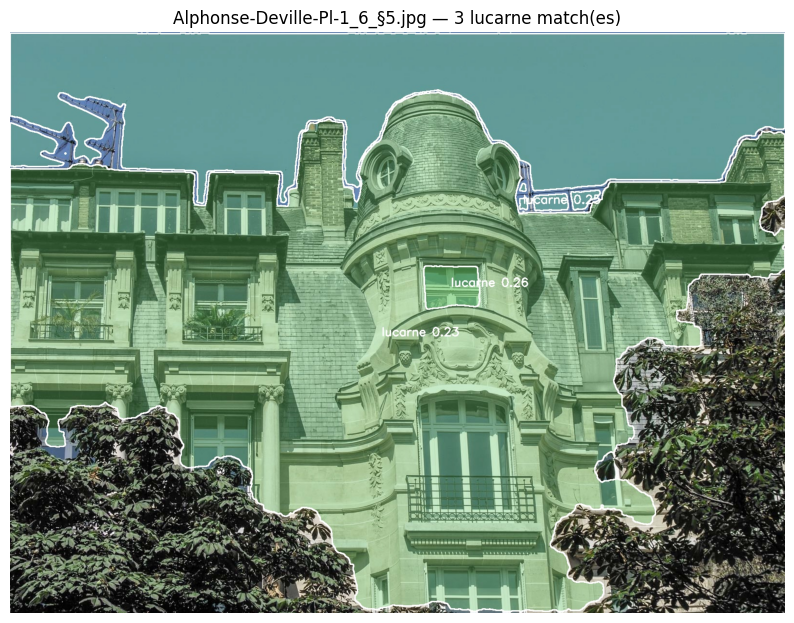

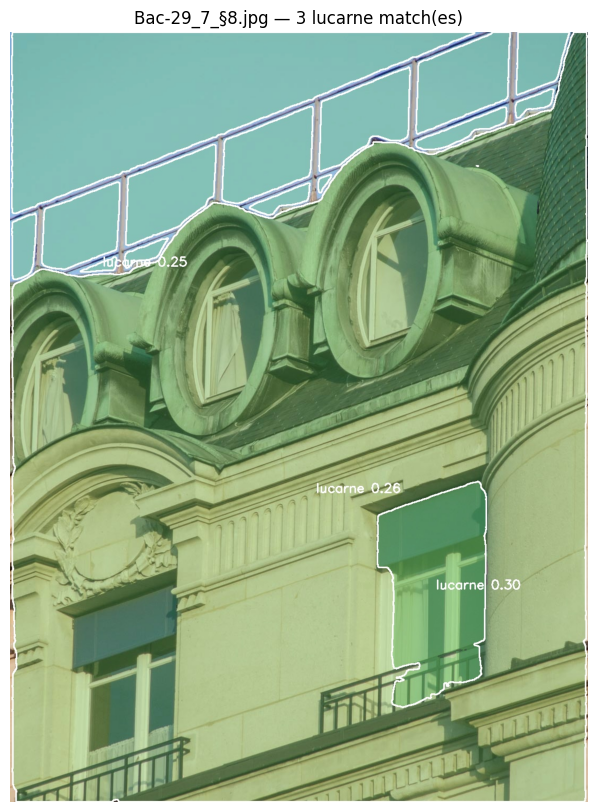

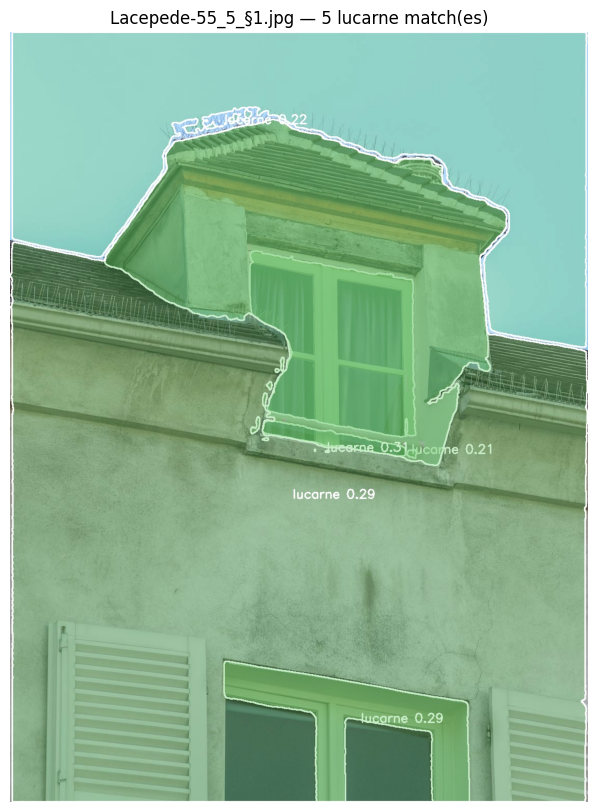

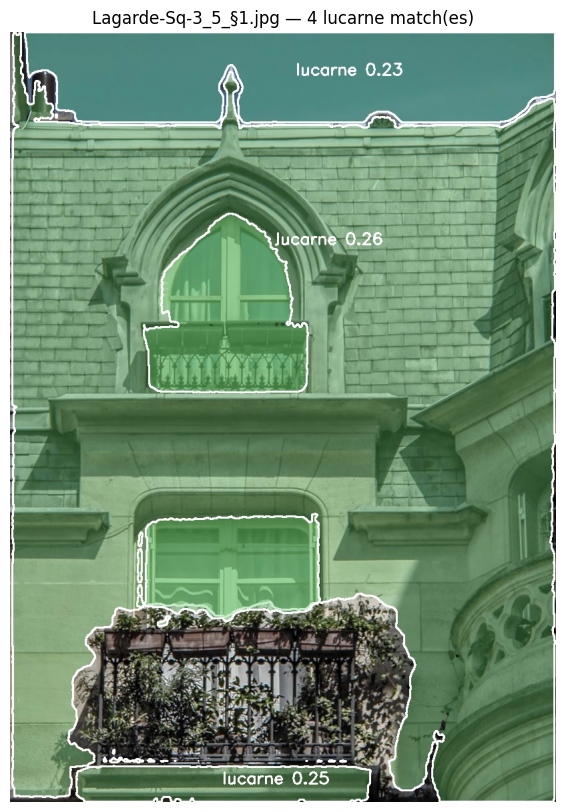

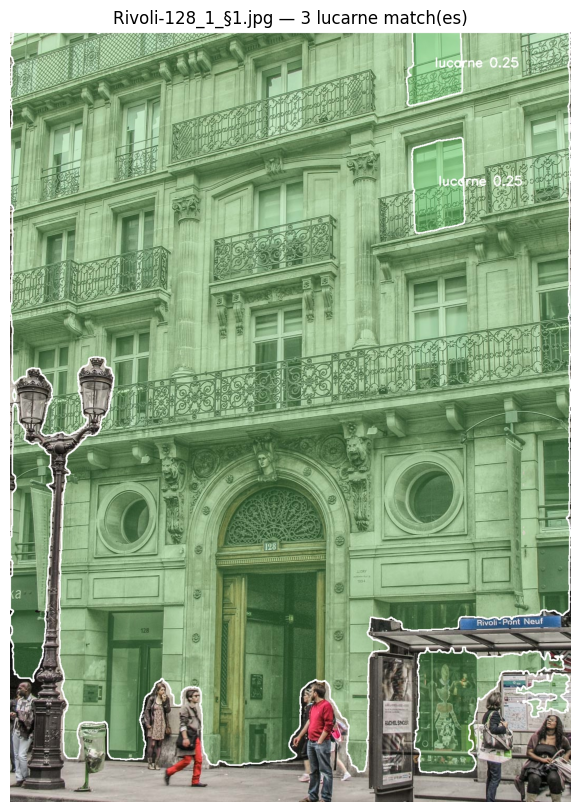

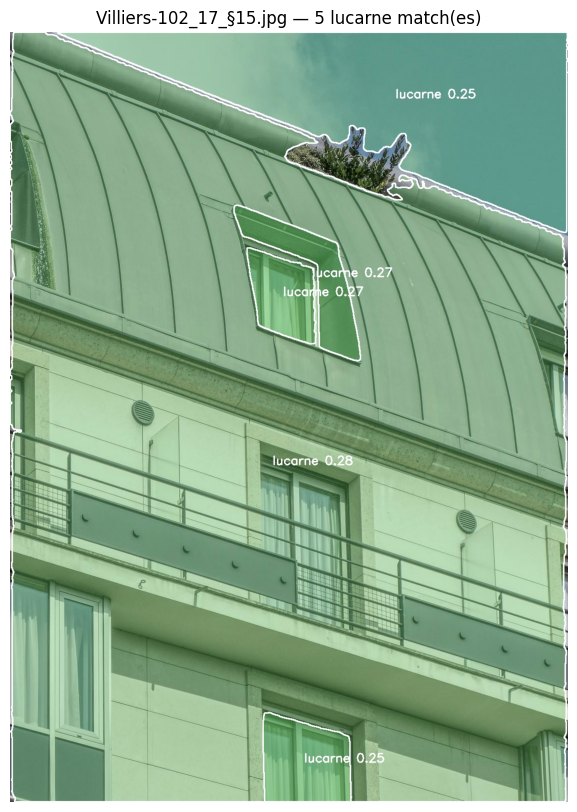

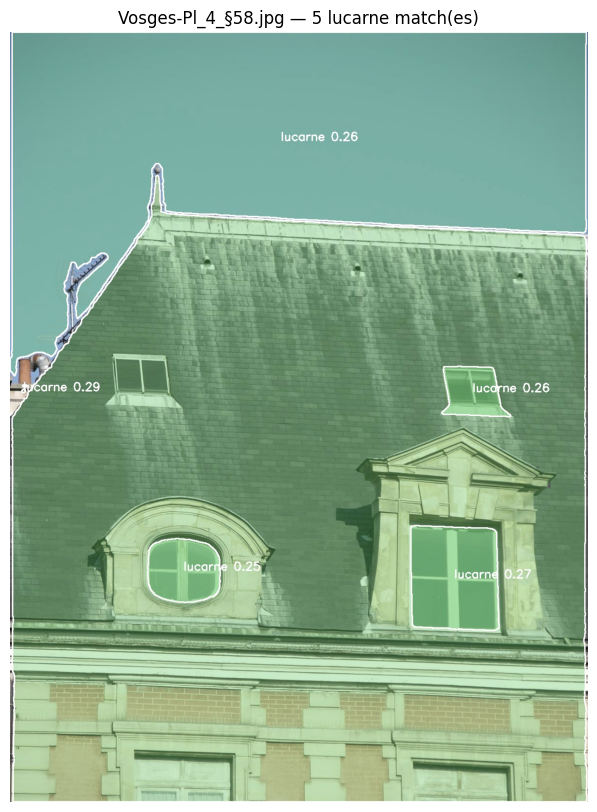

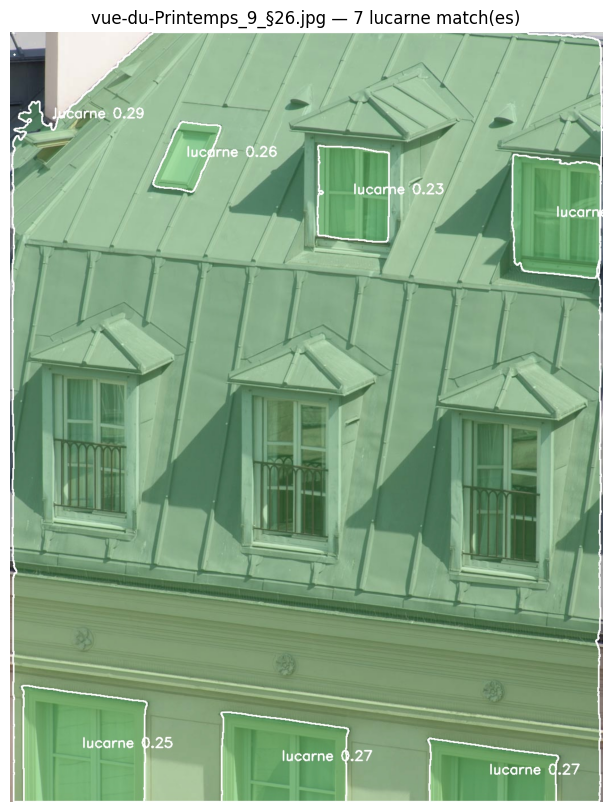

In [ ]:
vis_dir = os.path.join(OUTPUT_DIR, "vis")
os.makedirs(vis_dir, exist_ok=True) # Ensure directory exists
vis_files = [f for f in os.listdir(vis_dir) if os.path.splitext(f)[1] in SUPPORTED_EXT]

for vf in vis_files:
    img = cv2.imread(os.path.join(vis_dir, vf))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    n_matches = sum(1 for r in all_results.get(vf, []) if r["matched"])
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(f"{vf} — {n_matches} lucarne match(es)")
    plt.axis("off")
    plt.show()